**Import Libraries**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

**Load Dataset**

In [29]:
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


**Check Columns**

In [30]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

**Clean Rating Columns**

In [32]:
df['rate'] = df['rate'].astype(str)

df['rate'] = pd.to_numeric(
    df['rate'].str.extract(r'(\d+\.\d+)')[0],
    errors='coerce'
)

df = df.dropna(subset=['rate'])

**Rename Cost Column**

In [33]:
df.rename(columns={
    'approx_cost(for two people)': 'approx_cost'
}, inplace=True)

**Clean Price Column**

In [34]:
df['approx_cost'] = df['approx_cost'].astype(str)
df['approx_cost'] = df['approx_cost'].str.replace(',', '')
df['approx_cost'] = pd.to_numeric(df['approx_cost'], errors='coerce')

df = df.dropna(subset=['approx_cost'])

**Clean Cuisines**

In [ ]:
df['cuisines'] = df['cuisines'].fillna("Unknown")
df['cuisines'] = df['cuisines'].str.lower()

**Cuisine v/s Rating**

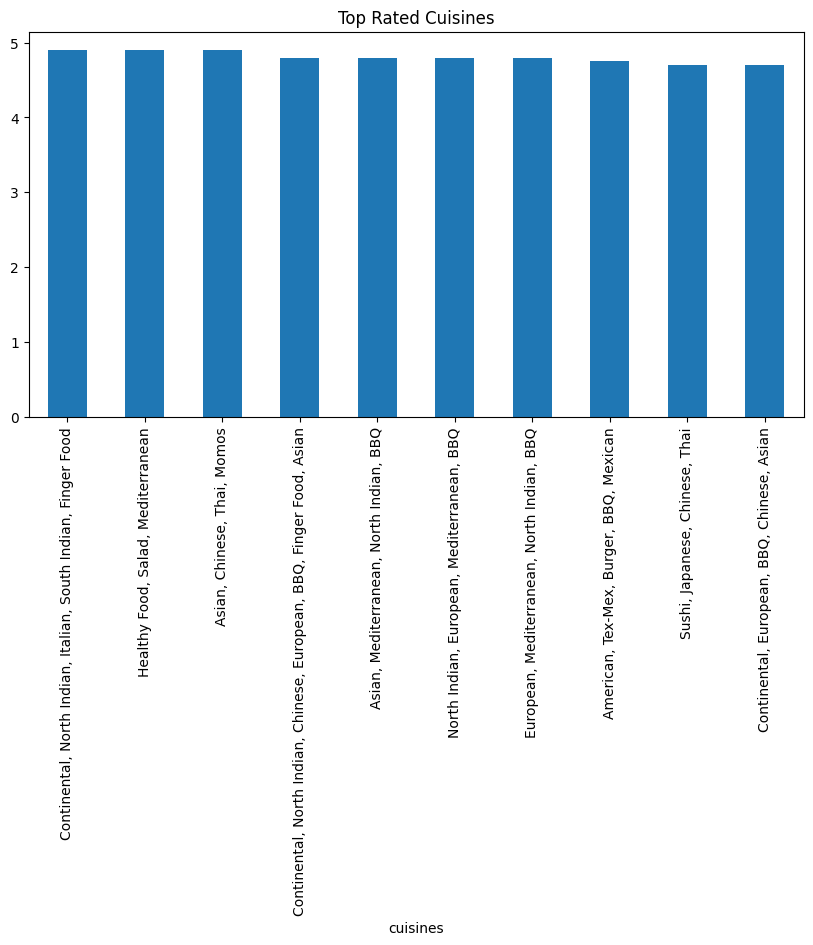

In [35]:
cuisine_rating = df.groupby('cuisines')['rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
cuisine_rating.head(10).plot(kind='bar')
plt.title("Top Rated Cuisines")
plt.show()

**Location Hotspot**

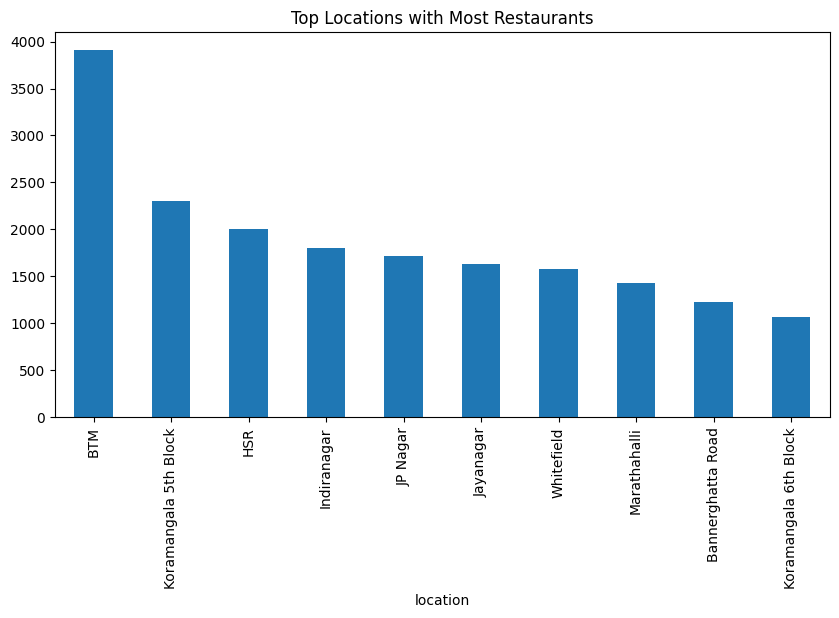

In [36]:
location_count = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
location_count.plot(kind='bar')
plt.title("Top Locations with Most Restaurants")
plt.show()

**Price vs Rating**

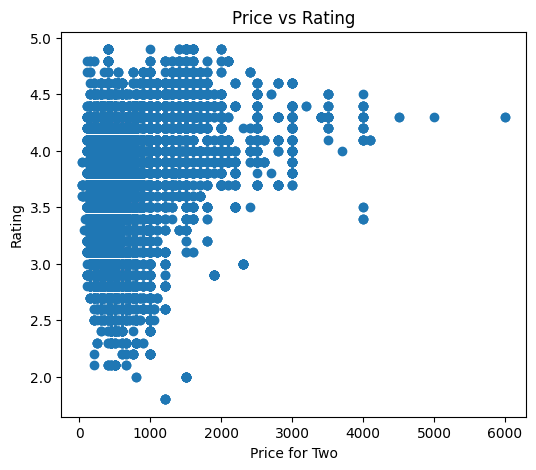

In [37]:
plt.figure(figsize=(6,5))
plt.scatter(df['approx_cost'], df['rate'])
plt.xlabel("Price for Two")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

**Heatmap**

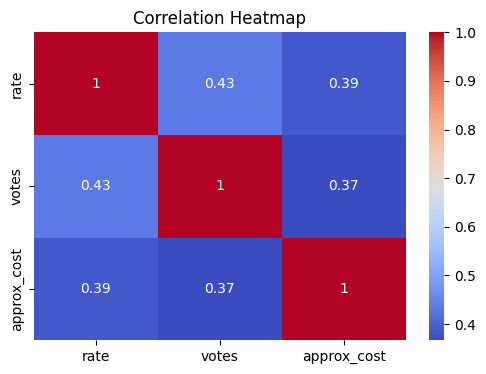

In [38]:
plt.figure(figsize=(6,4))
corr = df[['rate','votes','approx_cost']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**WordCloud**

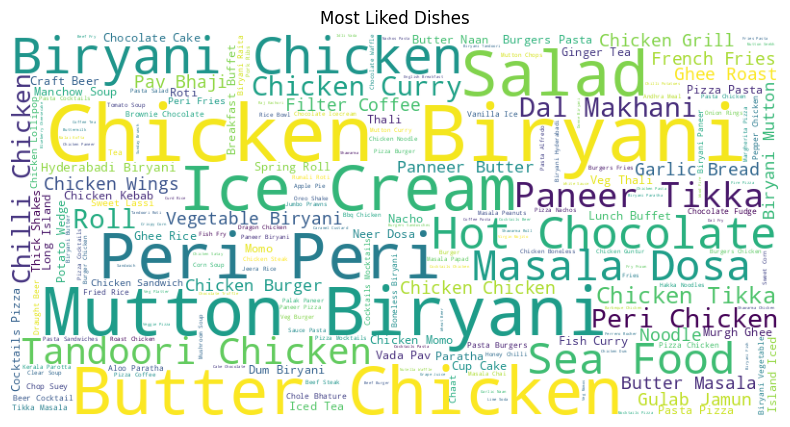

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert to string and remove null
text = " ".join(df['dish_liked'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Liked Dishes")
plt.show()